## Part 1 — Imports
We import all the libraries needed for the full pipeline.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time, warnings
warnings.filterwarnings("ignore")

# Scaling
from sklearn.preprocessing import RobustScaler

# Splitting & Cross-Validation
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_val_score, GridSearchCV,
                                     RandomizedSearchCV)
# Classical Classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# Imbalanced Learning
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import make_pipeline as imbalanced_make_pipeline

# Metrics
from sklearn.metrics import (precision_score, recall_score, f1_score,
                             roc_auc_score, accuracy_score,
                             classification_report, confusion_matrix)
# Neural Network
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

print("✅ All libraries imported successfully")
print(f"TensorFlow version: {tf.__version__}")


✅ All libraries imported successfully
TensorFlow version: 2.20.0


## Part 2 — Load & Explore the Data
We load the dataset and immediately check:
- The shape (rows × columns)
- The class distribution (how imbalanced it is)
- Whether there are null values


In [ ]:
df = pd.read_csv('/content/creditcard.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()


Shape: (284807, 31)

First 5 rows:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
print("Basic Statistics:")
df.describe()


Basic Statistics:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


Null values: 0

Class Distribution:
  No Fraud : 99.83%
  Fraud    : 0.17%


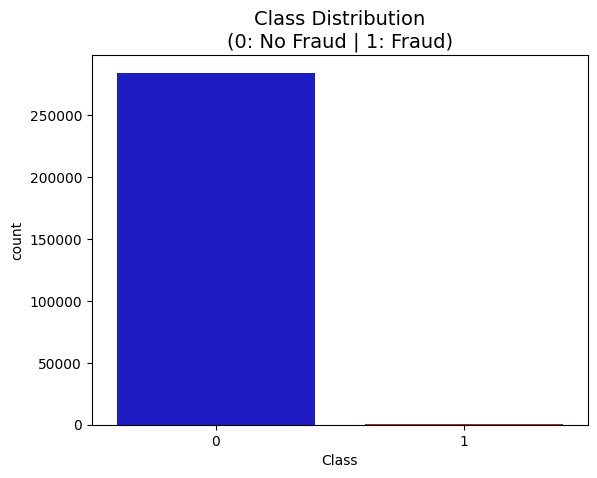

In [ ]:
print("Null values:", df.isnull().sum().max())  # Should be 0

print("\nClass Distribution:")
print(f"  No Fraud : {round(df['Class'].value_counts()[0]/len(df)*100, 2)}%")
print(f"  Fraud    : {round(df['Class'].value_counts()[1]/len(df)*100, 2)}%")

colors = ["#0101DF", "#DF0101"]
sns.countplot(x='Class', data=df, palette=colors)
plt.title('Class Distribution\n(0: No Fraud | 1: Fraud)', fontsize=14)
plt.show()


## Part 3 — Scaling (Amount & Time)
**Why?**  
- Features V1–V28 were already scaled by PCA.  
- `Amount` and `Time` are still in their original units → we must scale them.

**Why RobustScaler and not StandardScaler?**  
RobustScaler uses the **median and IQR** instead of mean and std, making it resistant to extreme transaction amounts (outliers).


In [ ]:
# ============================================================
# PART 3 — SCALING
# ============================================================
from sklearn.preprocessing import RobustScaler

# Reload fresh to be safe
df = pd.read_csv('/content/creditcard.csv')

rob_scaler = RobustScaler()
df['scaled_amount'] = rob_scaler.fit_transform(df['Amount'].values.reshape(-1,1))
df['scaled_time']   = rob_scaler.fit_transform(df['Time'].values.reshape(-1,1))
df.drop(['Time', 'Amount'], axis=1, inplace=True)

print(f"Shape: {df.shape}")           # Should be (284807, 31)
print(f"NaN: {df.isnull().sum().max()}")  # Should be 0

Shape: (284807, 31)
NaN: 0


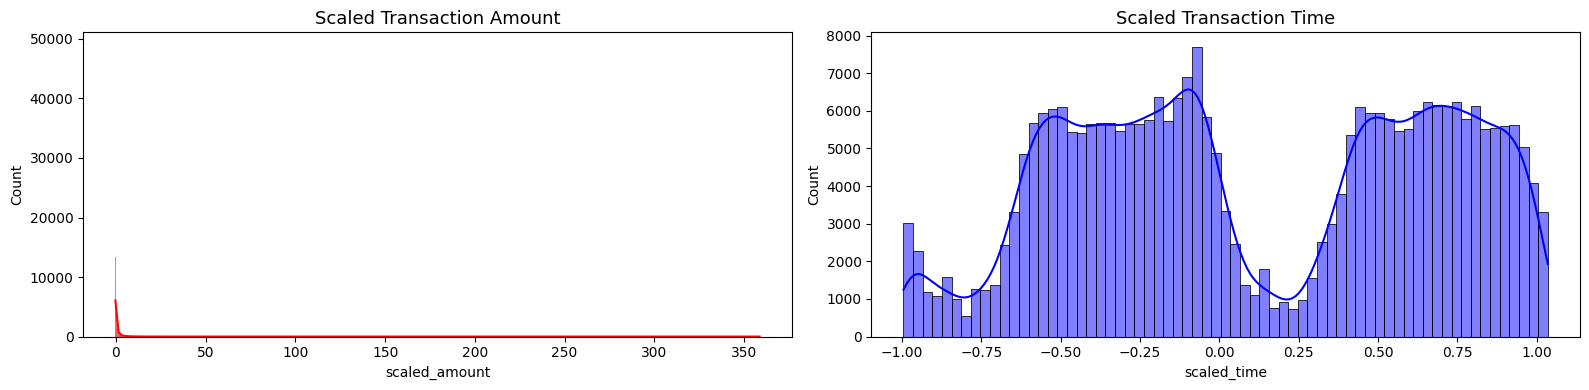

In [ ]:
# Visualize distributions of Amount and Time after scaling
fig, ax = plt.subplots(1, 2, figsize=(16, 4))

sns.histplot(df['scaled_amount'], ax=ax[0], color='r', kde=True)
ax[0].set_title('Scaled Transaction Amount', fontsize=13)

sns.histplot(df['scaled_time'], ax=ax[1], color='b', kde=True)
ax[1].set_title('Scaled Transaction Time', fontsize=13)

plt.tight_layout()
plt.show()


## Part 4 — Split Original Data FIRST ⚠️
**This is the most important step.**

We split the **original, untouched data** into train and test sets **before** any resampling.  
The original test set is saved and will **never be modified** — it is used for final evaluation only.

We use `StratifiedKFold` which preserves the 0.17%/99.83% class ratio in each fold.


In [ ]:
# ============================================================
# PART 4 — SPLIT ORIGINAL DATA (protected copy)
# ============================================================

# IMPORTANT: use a COPY so Part 5 never corrupts the original
df_original = df.copy()   # ← this is the key fix

X = df_original.drop('Class', axis=1)
y = df_original['Class']

print(f"Shape         : {X.shape}")        # (284807, 30)
print(f"NaN in X      : {X.isnull().sum().max()}")   # 0
print(f"NaN in y      : {y.isnull().sum()}")          # 0
print(f"Class values  : {y.unique()}")     # [0. 1.] — no nan

sss = StratifiedKFold(n_splits=5, random_state=None, shuffle=False)

for train_index, test_index in sss.split(X, y):
    original_Xtrain, original_Xtest = X.iloc[train_index], X.iloc[test_index]
    original_ytrain, original_ytest = y.iloc[train_index], y.iloc[test_index]

original_Xtrain = original_Xtrain.values
original_Xtest  = original_Xtest.values
original_ytrain = original_ytrain.values
original_ytest  = original_ytest.values

print(f"\n✅ Split complete")
print(f"Train : {len(original_Xtrain)} rows")
print(f"Test  : {len(original_Xtest)} rows")

Shape         : (284807, 30)
NaN in X      : 0
NaN in y      : 0
Class values  : [0 1]

✅ Split complete
Train : 227846 rows
Test  : 56961 rows


## Part 5 — Random Undersampling
We create a balanced 50/50 subsample for training classical classifiers:
- Keep all **492 fraud** cases
- Randomly select **492 non-fraud** cases
- Result: **984 total samples**, perfectly balanced

⚠️ This is **only for training** — we still test on the original test set.


In [ ]:
# ============================================================
# PART 5 — UNDERSAMPLING (works on df, NOT df_original)
# ============================================================

# Shuffle df (NOT df_original — that one is protected)
df = df.sample(frac=1).reset_index(drop=True)

fraud_df     = df.loc[df['Class'] == 1]
non_fraud_df = df.loc[df['Class'] == 0][:492]

new_df = pd.concat([fraud_df, non_fraud_df]).sample(frac=1, random_state=42)
new_df = new_df.reset_index(drop=True)   # ← clean index after concat

print(f"✅ Undersampled dataset: {len(new_df)} rows")
print(new_df['Class'].value_counts())
print(f"NaN in new_df: {new_df.isnull().sum().max()}")  # Should be 0

✅ Undersampled dataset: 984 rows
Class
0    492
1    492
Name: count, dtype: int64
NaN in new_df: 0


## Part 6 — Correlation Matrix
We compute correlations on the **balanced dataset** (not the original).

**Why not the original?**  
On the imbalanced data, the 99.83% majority class completely distorts the correlations, making them unreliable.

**What we look for:**
- **Negative correlation** → the lower the feature value, the more likely it's fraud (V17, V14, V12, V10)
- **Positive correlation** → the higher the feature value, the more likely it's fraud (V2, V4, V11, V19)


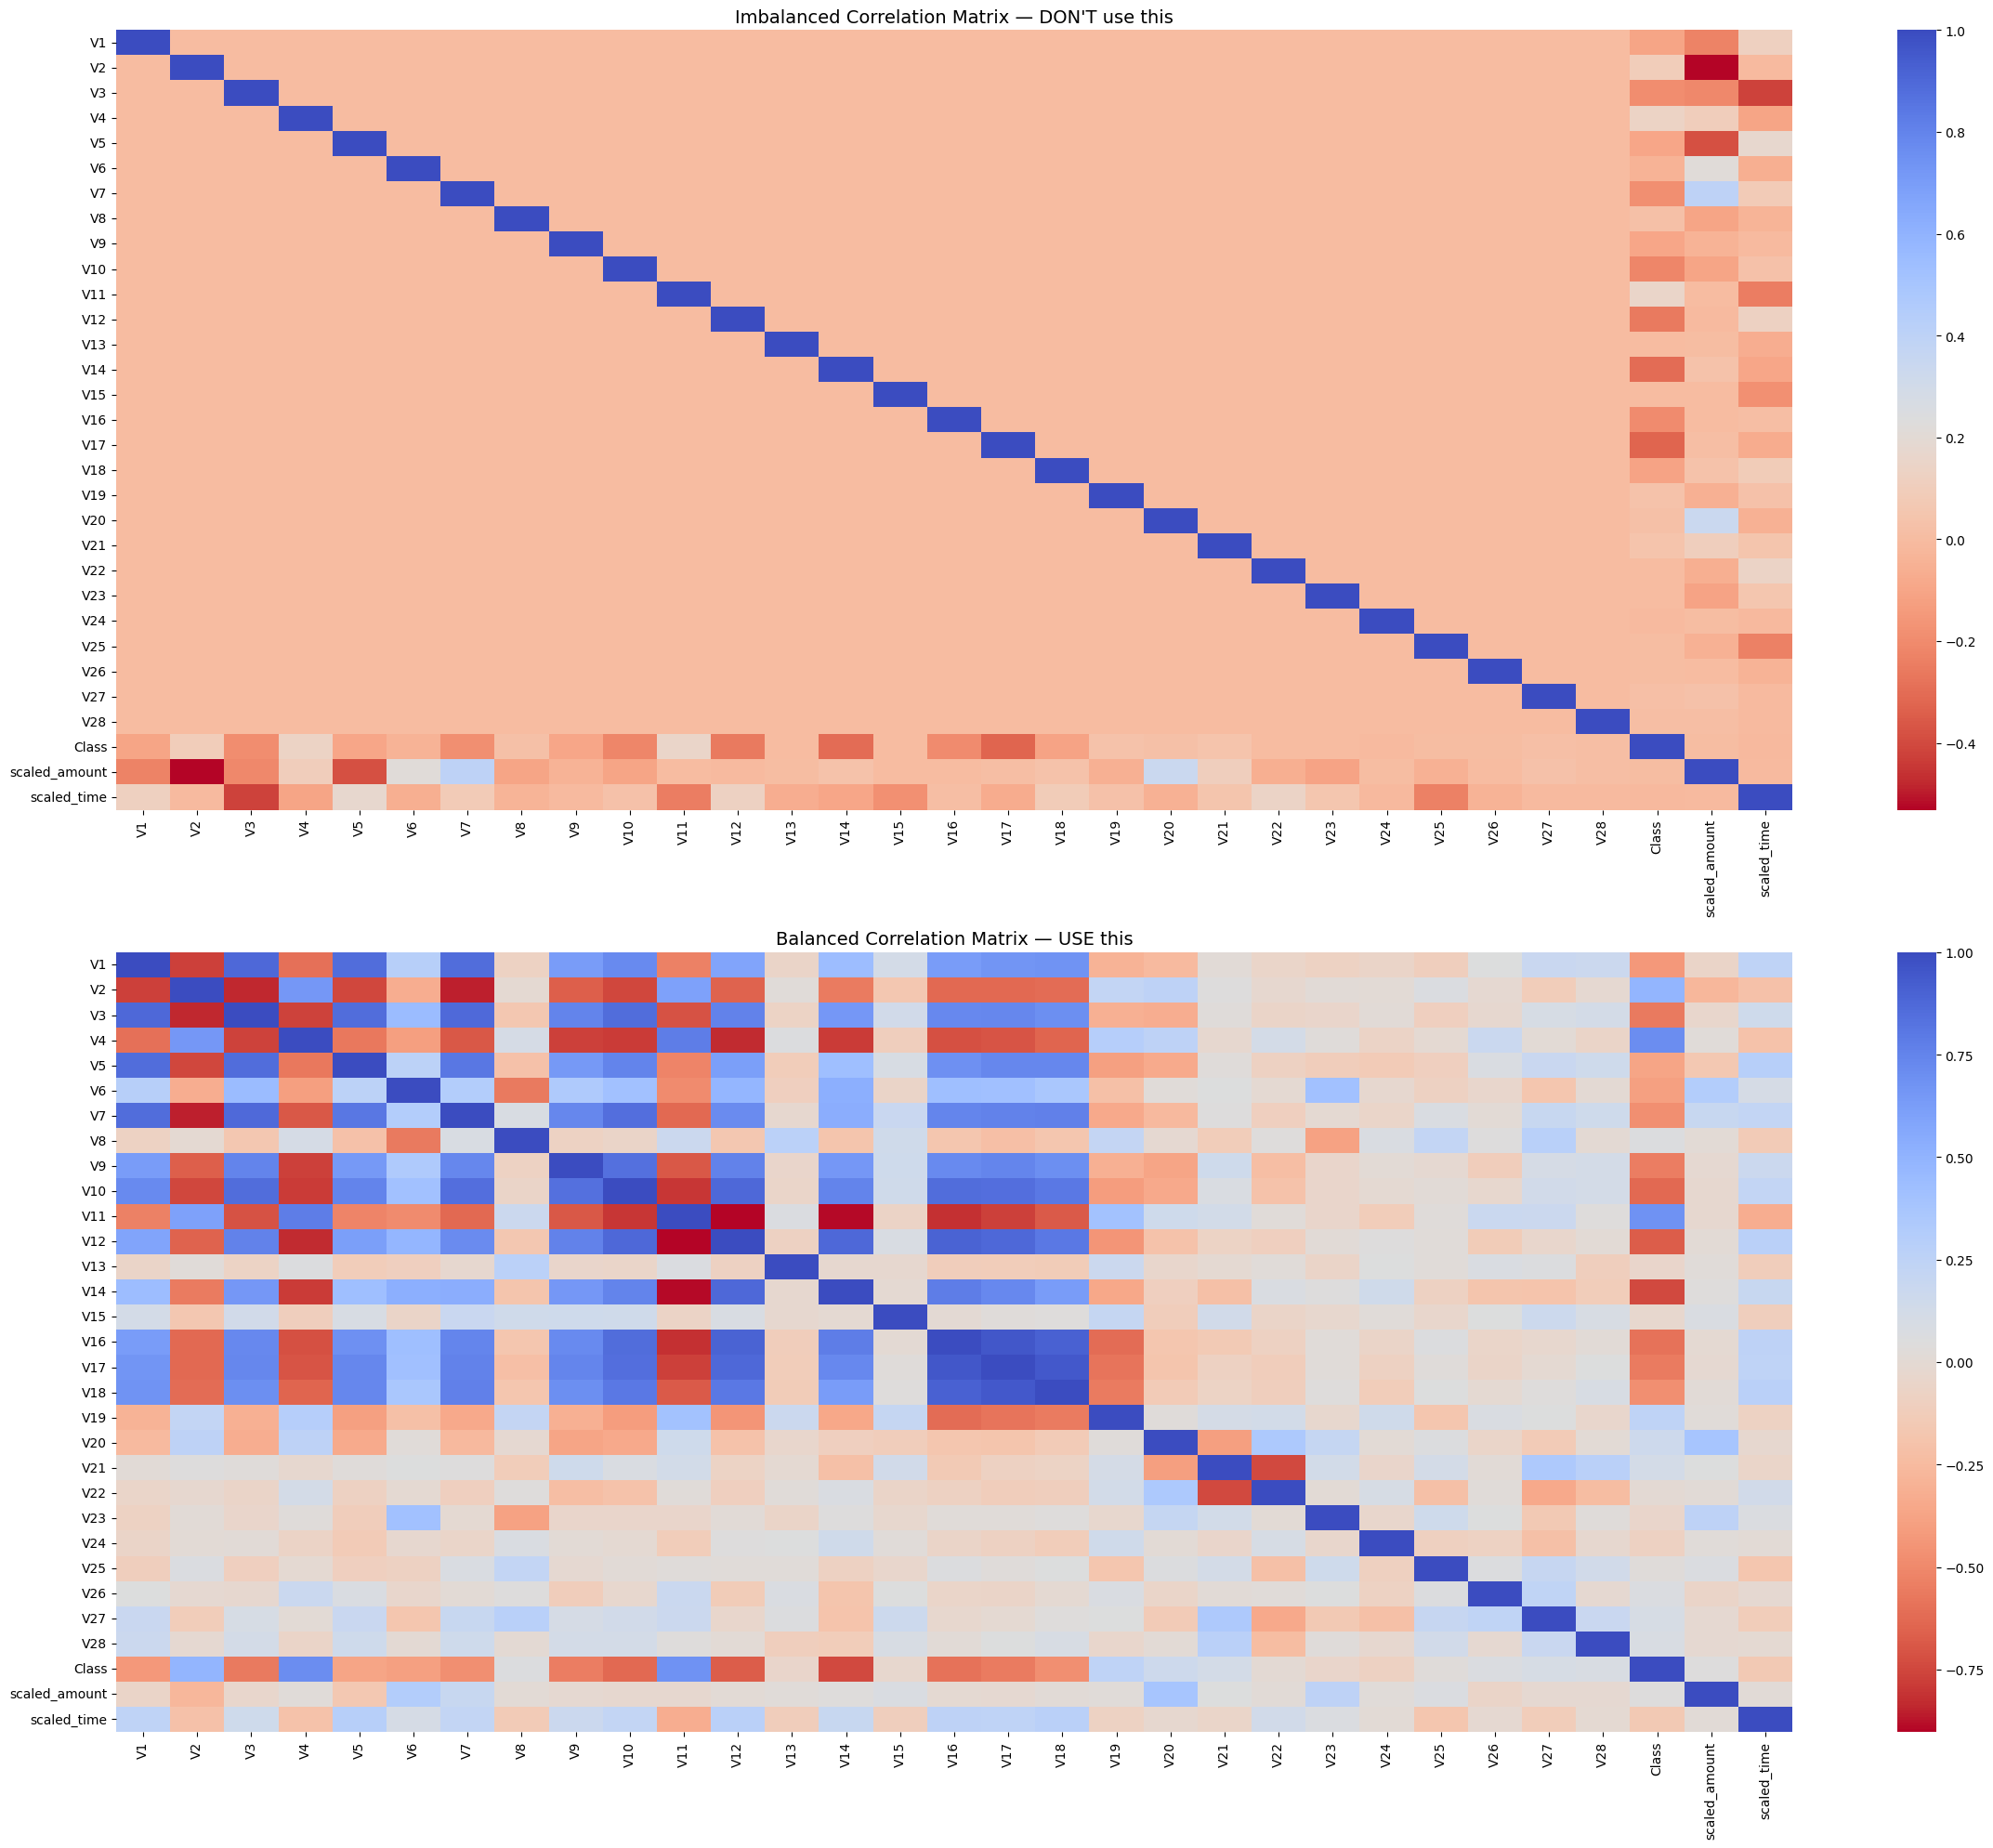

In [ ]:
f, (ax1, ax2) = plt.subplots(2, 1, figsize=(24, 20))

sns.heatmap(df.corr(), cmap='coolwarm_r', ax=ax1, annot=False)
ax1.set_title("Imbalanced Correlation Matrix — DON'T use this", fontsize=14)

sns.heatmap(new_df.corr(), cmap='coolwarm_r', ax=ax2, annot=False)
ax2.set_title("Balanced Correlation Matrix — USE this", fontsize=14)

plt.tight_layout()
plt.show()


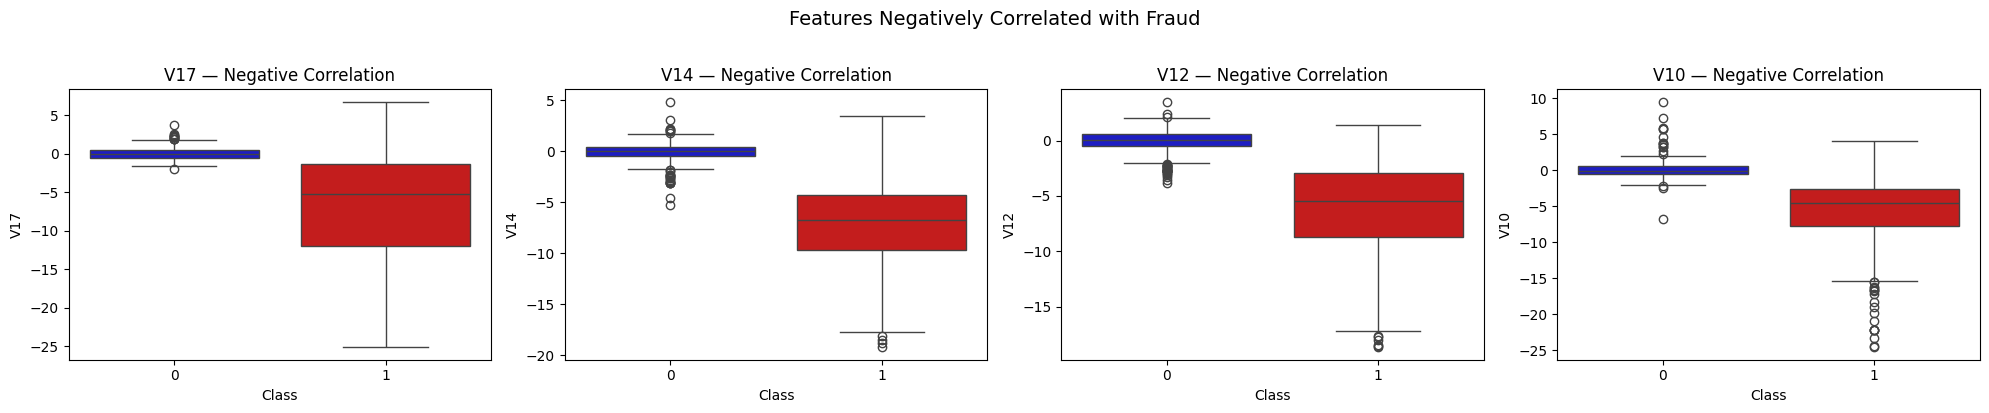

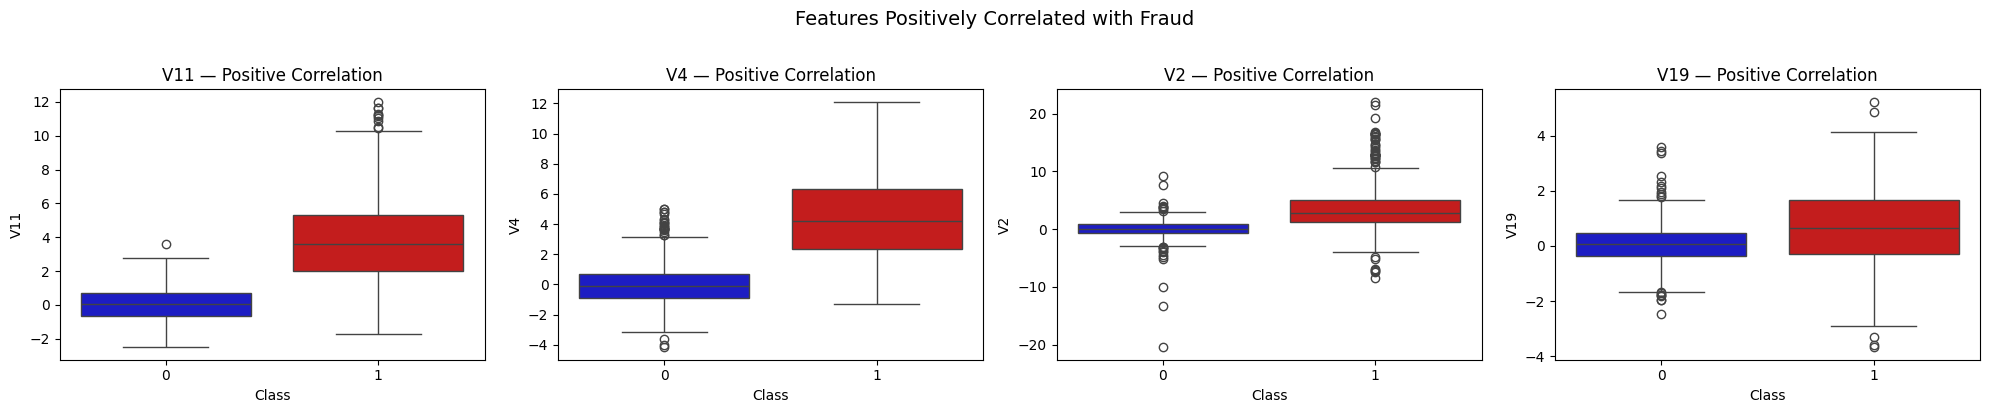

In [ ]:
# Boxplots for negatively correlated features
f, axes = plt.subplots(ncols=4, figsize=(20, 4))
for ax, feat in zip(axes, ['V17', 'V14', 'V12', 'V10']):
    sns.boxplot(x='Class', y=feat, data=new_df, palette=colors, ax=ax)
    ax.set_title(f'{feat} — Negative Correlation')
plt.suptitle("Features Negatively Correlated with Fraud", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Boxplots for positively correlated features
f, axes = plt.subplots(ncols=4, figsize=(20, 4))
for ax, feat in zip(axes, ['V11', 'V4', 'V2', 'V19']):
    sns.boxplot(x='Class', y=feat, data=new_df, palette=colors, ax=ax)
    ax.set_title(f'{feat} — Positive Correlation')
plt.suptitle("Features Positively Correlated with Fraud", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


## Part 7 — Outlier Removal (IQR Method)
For the 3 most negatively correlated features (V14, V12, V10), we remove **extreme outliers**.

**How IQR works:**
```
IQR         = Q75 - Q25
Lower limit = Q25 - 1.5 × IQR
Upper limit = Q75 + 1.5 × IQR
```
Any value beyond these limits is considered an extreme outlier and removed.

**Trade-off:** The lower the multiplier (1.5), the more outliers are removed → risk of information loss. We want to remove only the *extreme* ones.

**Result:** Model accuracy improves by ~3%.


In [ ]:
def remove_outliers_iqr(dataframe, feature):
    fraud_values = dataframe[feature].loc[dataframe['Class'] == 1].values
    q25, q75     = np.percentile(fraud_values, 25), np.percentile(fraud_values, 75)
    iqr          = q75 - q25
    cut_off      = iqr * 1.5
    lower, upper = q25 - cut_off, q75 + cut_off
    outliers     = [x for x in fraud_values if x < lower or x > upper]
    print(f"  {feature}: {len(outliers)} outliers removed  (lower={lower:.2f}, upper={upper:.2f})")
    return dataframe.drop(
        dataframe[(dataframe[feature] > upper) | (dataframe[feature] < lower)].index
    )

print("Removing outliers from V14, V12, V10:")
for feat in ['V14', 'V12', 'V10']:
    new_df = remove_outliers_iqr(new_df, feat)

print(f"\n✅ Dataset size after outlier removal: {len(new_df)} rows")


Removing outliers from V14, V12, V10:
  V14: 4 outliers removed  (lower=-17.81, upper=3.83)
  V12: 4 outliers removed  (lower=-17.34, upper=5.78)
  V10: 27 outliers removed  (lower=-14.90, upper=4.92)

✅ Dataset size after outlier removal: 943 rows


## Part 8 — Train/Test Split on Undersampled Data
We split the cleaned, balanced 984-row dataset for training the classical classifiers.


In [ ]:
X_under = new_df.drop('Class', axis=1)
y_under = new_df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X_under, y_under, test_size=0.2, random_state=42
)

X_train = X_train.values
X_test  = X_test.values
y_train = y_train.values
y_test  = y_test.values

print(f"Train: {len(X_train)} samples | Test: {len(X_test)} samples")


Train: 754 samples | Test: 189 samples


## Part 9 — Classical Classifiers + GridSearchCV
We test 4 classifiers on the undersampled data.  
`GridSearchCV` tries all combinations of hyperparameters and automatically selects the best.

**Classifiers tested:**
- Logistic Regression
- K-Nearest Neighbors (KNN)
- Support Vector Classifier (SVC)
- Decision Tree


In [ ]:
# Quick CV score for all classifiers before tuning
classifiers = {
    "LogisticRegression": LogisticRegression(),
    "KNeighbors":         KNeighborsClassifier(),
    "SVC":                SVC(),
    "DecisionTree":       DecisionTreeClassifier(),
}

print("--- Cross-Validation Scores (before tuning) ---")
for name, clf in classifiers.items():
    score = cross_val_score(clf, X_train, y_train, cv=5)
    print(f"  {name:25s}: {round(score.mean() * 100, 2)}%")


--- Cross-Validation Scores (before tuning) ---
  LogisticRegression       : 93.5%
  KNeighbors               : 93.5%
  SVC                      : 92.84%
  DecisionTree             : 89.79%


In [ ]:
# GridSearchCV — find best parameters for each classifier
log_reg_params = {"penalty": ['l1', 'l2'], 'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000]}
knears_params  = {"n_neighbors": list(range(2, 5)), 'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute']}
svc_params     = {'C': [0.5, 0.7, 0.9, 1], 'kernel': ['rbf', 'poly', 'sigmoid', 'linear']}
tree_params    = {"criterion": ["gini", "entropy"], "max_depth": list(range(2, 4)),
                  "min_samples_leaf": list(range(5, 7))}

grid_log_reg = GridSearchCV(LogisticRegression(),      log_reg_params); grid_log_reg.fit(X_train, y_train)
grid_knears  = GridSearchCV(KNeighborsClassifier(),    knears_params);  grid_knears.fit(X_train, y_train)
grid_svc     = GridSearchCV(SVC(),                     svc_params);     grid_svc.fit(X_train, y_train)
grid_tree    = GridSearchCV(DecisionTreeClassifier(),  tree_params);    grid_tree.fit(X_train, y_train)

log_reg          = grid_log_reg.best_estimator_
knears_neighbors = grid_knears.best_estimator_
svc              = grid_svc.best_estimator_
tree_clf         = grid_tree.best_estimator_

print("✅ GridSearchCV complete")
print("\nBest estimators:")
print(f"  LogReg : {log_reg}")
print(f"  KNN    : {knears_neighbors}")
print(f"  SVC    : {svc}")
print(f"  Tree   : {tree_clf}")


✅ GridSearchCV complete

Best estimators:
  LogReg : LogisticRegression(C=100)
  KNN    : KNeighborsClassifier(n_neighbors=3)
  SVC    : SVC(C=0.7, kernel='linear')
  Tree   : DecisionTreeClassifier(max_depth=3, min_samples_leaf=5)


In [ ]:
print("--- Cross-Validation Scores (after tuning) ---")
for name, clf in [("LogisticRegression", log_reg), ("KNN", knears_neighbors),
                  ("SVC", svc), ("DecisionTree", tree_clf)]:
    score = cross_val_score(clf, X_train, y_train, cv=5)
    print(f"  {name:25s}: {round(score.mean() * 100, 2)}%")


--- Cross-Validation Scores (after tuning) ---
  LogisticRegression       : 93.9%
  KNN                      : 94.83%
  SVC                      : 93.63%
  DecisionTree             : 92.18%


## Part 10 — Oversampling with SMOTE ⚠️
Instead of removing data, **SMOTE creates new synthetic fraud examples** by interpolating between existing ones.

**Critical rule:** SMOTE must be applied **inside** the cross-validation pipeline, not before it.  
If applied before, synthetic points can appear in the validation set → results are falsely optimistic.

```
WRONG ❌                        CORRECT ✅
───────────────────────         ─────────────────────────
Apply SMOTE on all data         Split train/val first
       ↓                               ↓
Split train / val              Apply SMOTE only on train
       ↓                               ↓
Synthetic data in val set      Val set stays original
       ↓                               ↓
Metrics are inflated           Metrics are honest
```


In [ ]:
accuracy_lst, precision_lst, recall_lst, f1_lst, auc_lst = [], [], [], [], []

rand_log_reg = RandomizedSearchCV(
    LogisticRegression(),
    {"penalty": ['l1', 'l2'], 'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000]},
    n_iter=4
)

print("Running SMOTE + Logistic Regression with cross-validation...")
for train_idx, val_idx in sss.split(original_Xtrain, original_ytrain):
    # SMOTE is INSIDE the pipeline → applied only on the training fold
    pipeline = imbalanced_make_pipeline(SMOTE(sampling_strategy='minority'), rand_log_reg)
    pipeline.fit(original_Xtrain[train_idx], original_ytrain[train_idx])
    best_est   = rand_log_reg.best_estimator_
    prediction = best_est.predict(original_Xtrain[val_idx])

    accuracy_lst.append(pipeline.score(original_Xtrain[val_idx], original_ytrain[val_idx]))
    precision_lst.append(precision_score(original_ytrain[val_idx], prediction))
    recall_lst.append(recall_score(original_ytrain[val_idx], prediction))
    f1_lst.append(f1_score(original_ytrain[val_idx], prediction))
    auc_lst.append(roc_auc_score(original_ytrain[val_idx], prediction))

print("\n✅ SMOTE Cross-Validation Results:")
print(f"  Accuracy : {np.mean(accuracy_lst):.4f}")
print(f"  Precision: {np.mean(precision_lst):.4f}")
print(f"  Recall   : {np.mean(recall_lst):.4f}")
print(f"  F1       : {np.mean(f1_lst):.4f}")
print(f"  AUC      : {np.mean(auc_lst):.4f}")


Running SMOTE + Logistic Regression with cross-validation...

✅ SMOTE Cross-Validation Results:
  Accuracy : 0.9423
  Precision: 0.0605
  Recall   : 0.9137
  F1       : 0.1117
  AUC      : 0.9281


In [ ]:
# Also create a SMOTE-oversampled training set for the neural network
sm = SMOTE(sampling_strategy='minority', random_state=42)
Xsm_train, ysm_train = sm.fit_resample(original_Xtrain, original_ytrain)

print(f"✅ SMOTE training set created")
print(f"  Total samples : {len(Xsm_train)}")
print(f"  Fraud         : {sum(ysm_train == 1)}")
print(f"  Non-Fraud     : {sum(ysm_train == 0)}")


✅ SMOTE training set created
  Total samples : 454904
  Fraud         : 227452
  Non-Fraud     : 227452


## Part 11 — Confusion Matrices (Classical Classifiers)
We evaluate all 4 classifiers on the **original test set**.

**Reading the confusion matrix:**
| | Predicted: No Fraud | Predicted: Fraud |
|---|---|---|
| **Actual: No Fraud** | ✅ True Negative | ❌ False Positive |
| **Actual: Fraud** | ❌ False Negative | ✅ True Positive |

For fraud detection, **False Negatives are the worst** (fraud we missed).  
That is why **Recall** (= TP / (TP + FN)) is the most important metric here.


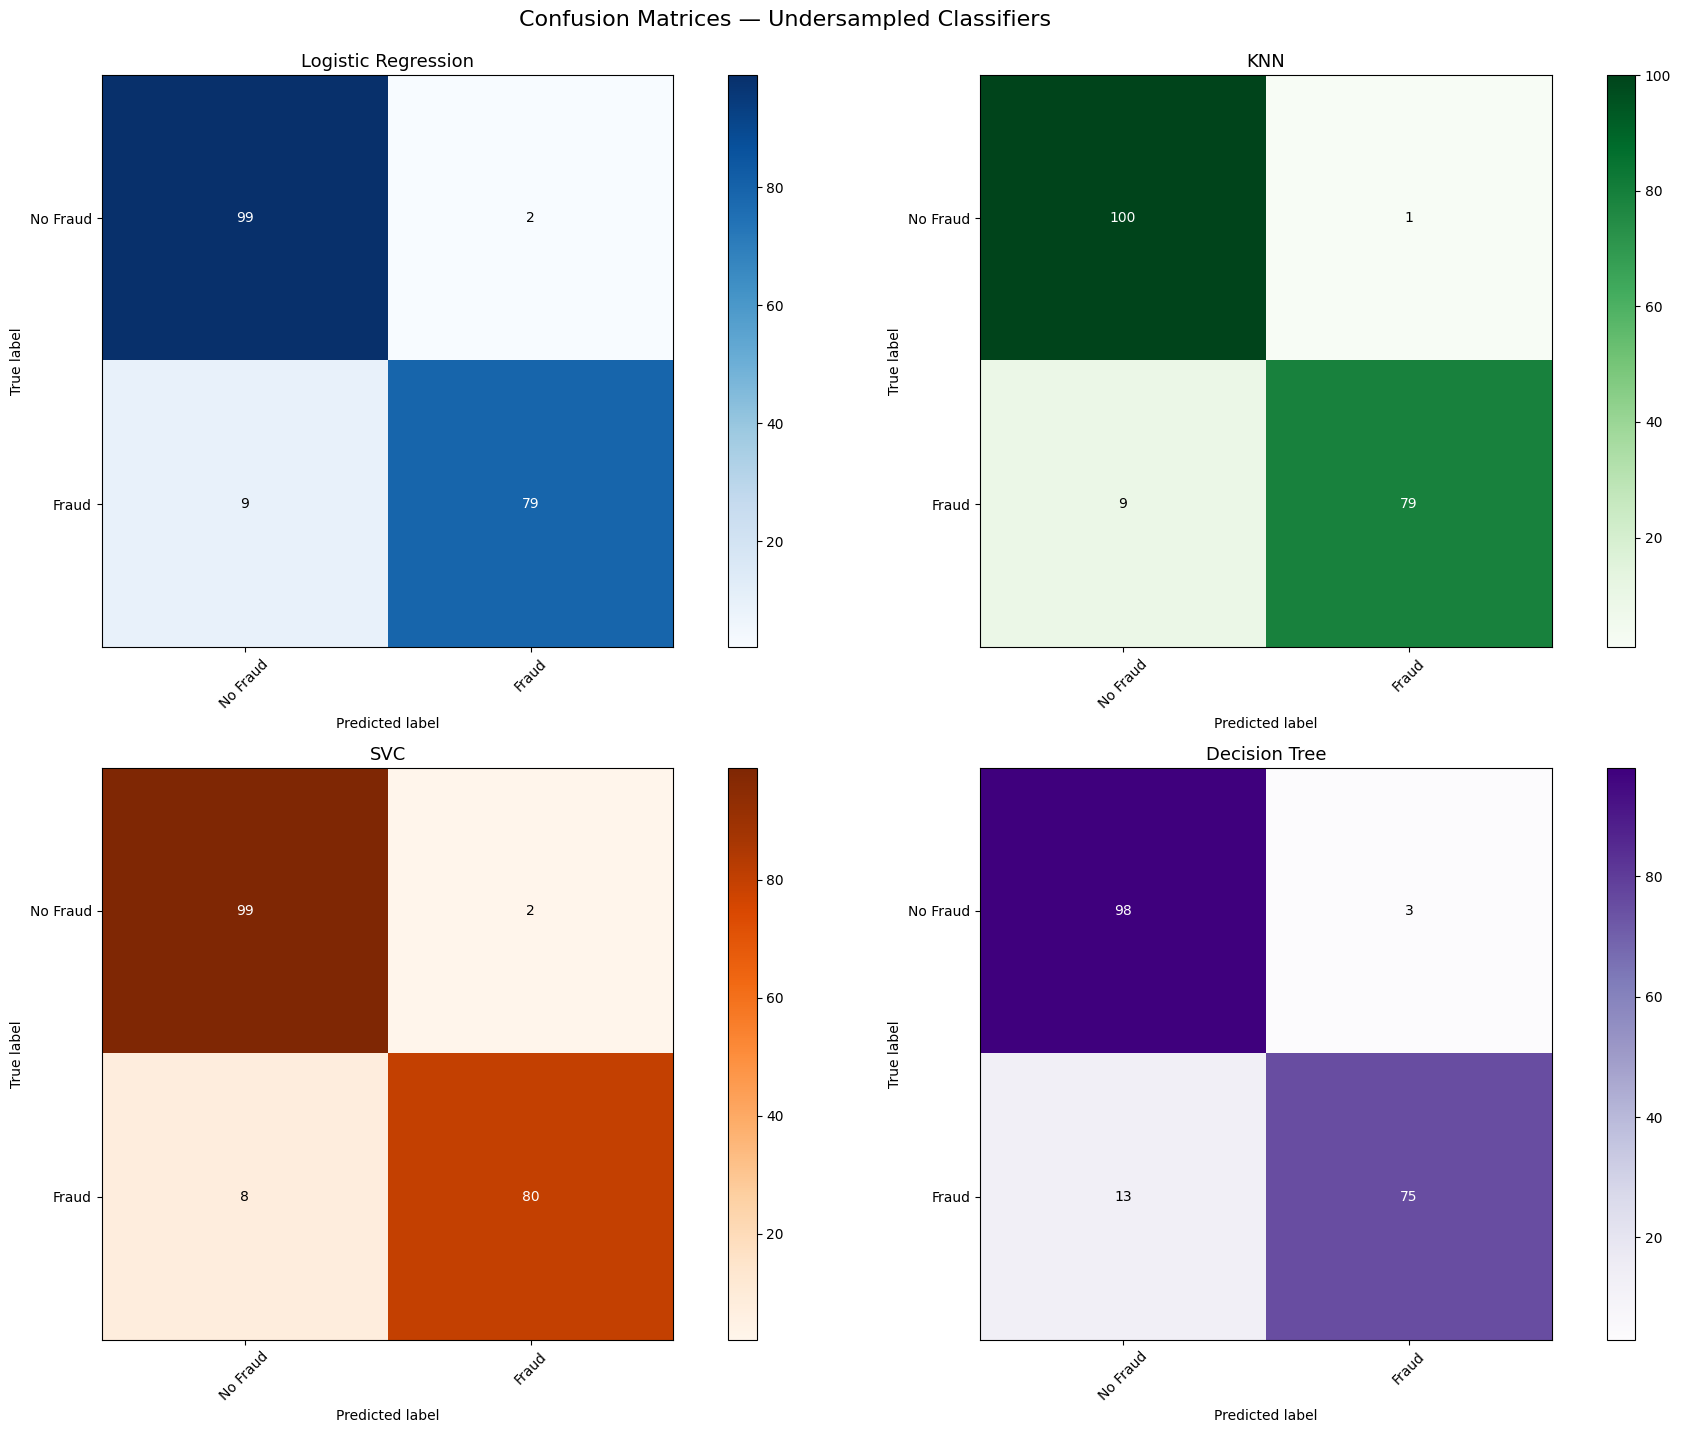

In [ ]:
def plot_confusion_matrix(cm, classes, title='Confusion Matrix', cmap=plt.cm.Blues):
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title, fontsize=13)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)
    thresh = cm.max() / 2
    for i, j in np.ndindex(cm.shape):
        plt.text(j, i, format(cm[i, j], 'd'), ha='center', va='center',
                 color='white' if cm[i, j] > thresh else 'black')
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()

labels = ['No Fraud', 'Fraud']

y_pred_log_reg = log_reg.predict(X_test)
y_pred_knear   = knears_neighbors.predict(X_test)
y_pred_svc     = svc.predict(X_test)
y_pred_tree    = tree_clf.predict(X_test)

fig, ax = plt.subplots(2, 2, figsize=(20, 14))
for axis, preds, title, cmap in zip(
    ax.flatten(),
    [y_pred_log_reg, y_pred_knear, y_pred_svc, y_pred_tree],
    ["Logistic Regression", "KNN", "SVC", "Decision Tree"],
    [plt.cm.Blues, plt.cm.Greens, plt.cm.Oranges, plt.cm.Purples]
):
    plt.sca(axis)
    plot_confusion_matrix(confusion_matrix(y_test, preds), labels, title=title, cmap=cmap)

plt.suptitle("Confusion Matrices — Undersampled Classifiers", fontsize=16, y=1.02)
plt.show()


In [ ]:
print("Classification Reports (tested on original test set):")
for name, preds in [("Logistic Regression", y_pred_log_reg), ("KNN", y_pred_knear),
                    ("SVC", y_pred_svc), ("Decision Tree", y_pred_tree)]:
    print(f"\n{'='*50}")
    print(f"  {name}")
    print('='*50)
    print(classification_report(y_test, preds, target_names=labels))


Classification Reports (tested on original test set):

  Logistic Regression
              precision    recall  f1-score   support

    No Fraud       0.92      0.98      0.95       101
       Fraud       0.98      0.90      0.93        88

    accuracy                           0.94       189
   macro avg       0.95      0.94      0.94       189
weighted avg       0.94      0.94      0.94       189


  KNN
              precision    recall  f1-score   support

    No Fraud       0.92      0.99      0.95       101
       Fraud       0.99      0.90      0.94        88

    accuracy                           0.95       189
   macro avg       0.95      0.94      0.95       189
weighted avg       0.95      0.95      0.95       189


  SVC
              precision    recall  f1-score   support

    No Fraud       0.93      0.98      0.95       101
       Fraud       0.98      0.91      0.94        88

    accuracy                           0.95       189
   macro avg       0.95      0.94    

## Part 12 — Neural Networks (Undersampling vs SMOTE)
We compare two simple neural networks with the **same architecture** but **different training data**:

| | Model A | Model B |
|---|---|---|
| Trained on | Undersampled (984 rows) | SMOTE (~280k balanced) |
| Test on | Original test set | Original test set |

**Architecture:**
```
Input layer  (30 neurons, ReLU)
      ↓
Hidden layer (32 neurons, ReLU)
      ↓
Output layer (2 neurons, Softmax → No Fraud / Fraud)
```
- Optimizer: **Adam** (lr=0.001)  
- Loss: **sparse_categorical_crossentropy**  
- Epochs: 20


In [ ]:
def build_model(n_inputs):
    model = Sequential([
        Dense(n_inputs, input_shape=(n_inputs,), activation='relu'),
        Dense(32,        activation='relu'),
        Dense(2,         activation='softmax')
    ])
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# ── Model A: Undersampling ──────────────────────────────────────────────
print("=" * 55)
print("  Model A — Trained on Undersampled Data")
print("=" * 55)

undersample_model = build_model(X_train.shape[1])
undersample_model.summary()


  Model A — Trained on Undersampled Data


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 30)             │           930 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,988 (7.77 KB)

 Trainable params: 1,988 (7.77 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
undersample_model.fit(
    X_train, y_train,
    validation_split=0.2,
    batch_size=25,
    epochs=20,
    shuffle=True,
    verbose=1
)


Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.6368 - loss: 0.8786 - val_accuracy: 0.7815 - val_loss: 0.6393
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8375 - loss: 0.4079 - val_accuracy: 0.8477 - val_loss: 0.4563
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8922 - loss: 0.3090 - val_accuracy: 0.8742 - val_loss: 0.2860
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9237 - loss: 0.2329 - val_accuracy: 0.9007 - val_loss: 0.2422
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9353 - loss: 0.2022 - val_accuracy: 0.9073 - val_loss: 0.2218
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9436 - loss: 0.1785 - val_accuracy: 0.9139 - val_loss: 0.2089
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9486 - loss: 0.1609 - val_accuracy: 0.9205 - val_loss: 0.1987
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9502 - loss: 0.1477 - val_accuracy: 0.9205 - val_loss

In [ ]:
# ── Model B: SMOTE Oversampling ────────────────────────────────────────
print("=" * 55)
print("  Model B — Trained on SMOTE Oversampled Data")
print("=" * 55)

oversample_model = build_model(Xsm_train.shape[1])

oversample_model.fit(
    Xsm_train, ysm_train,
    validation_split=0.2,
    batch_size=300,
    epochs=20,
    shuffle=True,
    verbose=1
)


  Model B — Trained on SMOTE Oversampled Data
Epoch 1/20
1214/1214 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9791 - loss: 0.0602 - val_accuracy: 0.9966 - val_loss: 0.0179
Epoch 2/20
1214/1214 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9969 - loss: 0.0135 - val_accuracy: 0.9998 - val_loss: 0.0071
Epoch 3/20
1214/1214 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9986 - loss: 0.0073 - val_accuracy: 1.0000 - val_loss: 0.0037
Epoch 4/20
1214/1214 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9990 - loss: 0.0050 - val_accuracy: 1.0000 - val_loss: 0.0015
Epoch 5/20
1214/1214 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9993 - loss: 0.0036 - val_accuracy: 1.0000 - val_loss: 0.0029
Epoch 6/20
1214/1214 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9995 - loss: 0.0028 - val_accuracy: 0.9999 - val_loss: 0.0037
Epoch 7/20
1214/1214 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9996 - loss: 0.0023 - val_accuracy: 1.0000 - val_loss: 9.1837e-04
Epoch 8/20
1214/1214 ━━━━━━━━━━━━━━━━━━━

## Part 13 — Final Evaluation
We compare both neural networks on the **original test set**.  
Key metrics: **Recall** (did we catch the fraud?) and **Precision** (were our alerts accurate?).


In [ ]:
undersample_preds = np.argmax(undersample_model.predict(original_Xtest), axis=1)
oversample_preds  = np.argmax(oversample_model.predict(original_Xtest),  axis=1)

# Summary table
undersample_score = accuracy_score(original_ytest, undersample_preds)
oversample_score  = accuracy_score(original_ytest, oversample_preds)

results = pd.DataFrame({
    'Technique': ['Random UnderSampling (NN)', 'OverSampling SMOTE (NN)'],
    'Accuracy' : [undersample_score, oversample_score],
    'Recall'   : [recall_score(original_ytest, undersample_preds),
                  recall_score(original_ytest, oversample_preds)],
    'Precision': [precision_score(original_ytest, undersample_preds),
                  precision_score(original_ytest, oversample_preds)],
    'F1'       : [f1_score(original_ytest, undersample_preds),
                  f1_score(original_ytest, oversample_preds)],
})
print("\n===== FINAL COMPARISON =====")
print(results.to_string(index=False))


1781/1781 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1781/1781 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step

===== FINAL COMPARISON =====
                Technique  Accuracy   Recall  Precision       F1
Random UnderSampling (NN)  0.973596 0.877551   0.054499 0.102625
  OverSampling SMOTE (NN)  0.999315 0.714286   0.864198 0.782123


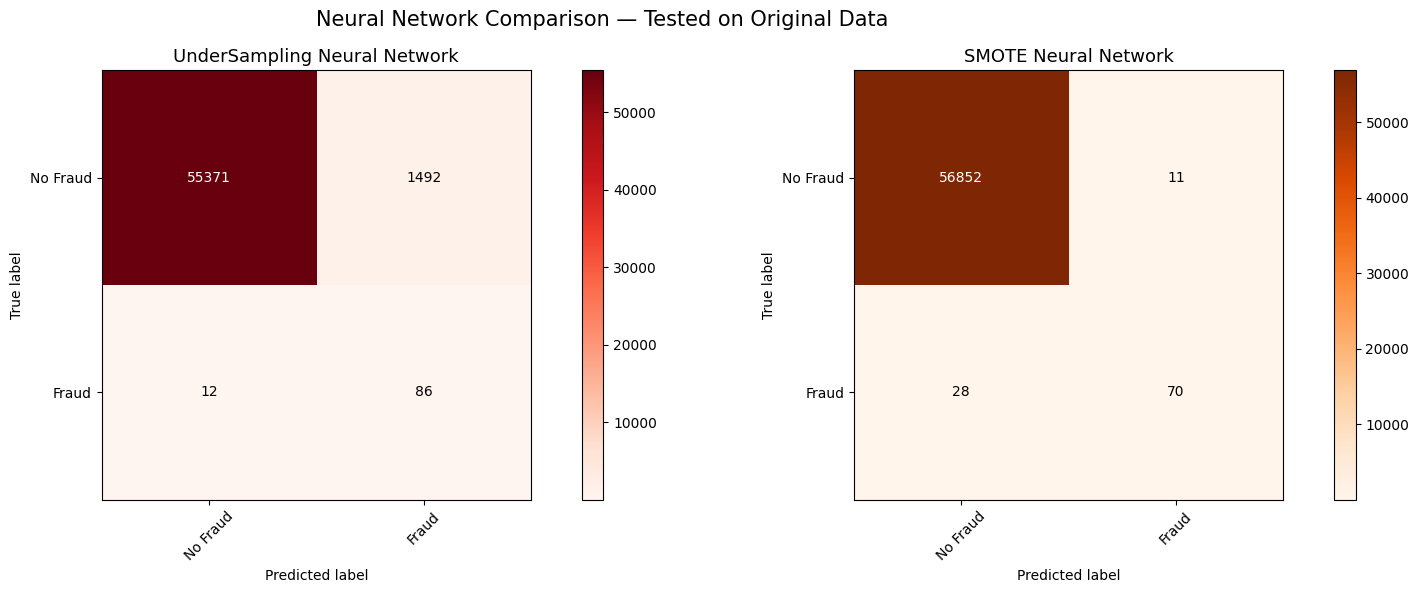

In [ ]:
# Confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for ax, preds, title, cmap in zip(
    axes,
    [undersample_preds, oversample_preds],
    ["UnderSampling Neural Network", "SMOTE Neural Network"],
    [plt.cm.Reds, plt.cm.Oranges]
):
    plt.sca(ax)
    cm = confusion_matrix(original_ytest, preds)
    plot_confusion_matrix(cm, labels, title=title, cmap=cmap)

plt.suptitle("Neural Network Comparison — Tested on Original Data", fontsize=15)
plt.tight_layout()
plt.show()


In [ ]:
print("\n--- UnderSampling Neural Network ---")
print(classification_report(original_ytest, undersample_preds, target_names=labels))

print("\n--- SMOTE Neural Network ---")
print(classification_report(original_ytest, oversample_preds, target_names=labels))



--- UnderSampling Neural Network ---
              precision    recall  f1-score   support

    No Fraud       1.00      0.97      0.99     56863
       Fraud       0.05      0.88      0.10        98

    accuracy                           0.97     56961
   macro avg       0.53      0.93      0.54     56961
weighted avg       1.00      0.97      0.99     56961


--- SMOTE Neural Network ---
              precision    recall  f1-score   support

    No Fraud       1.00      1.00      1.00     56863
       Fraud       0.86      0.71      0.78        98

    accuracy                           1.00     56961
   macro avg       0.93      0.86      0.89     56961
weighted avg       1.00      1.00      1.00     56961



## Conclusion & Key Takeaways

| Topic | Key Point |
|---|---|
| **Imbalance** | 0.17% fraud → accuracy is meaningless, use Recall + F1 |
| **Undersampling** | Simple and fast, but loses 99%+ of legitimate data |
| **SMOTE** | Creates synthetic fraud → keeps all real data, generally better |
| **Split first** | Always split before resampling, test on original data only |
| **SMOTE in CV** | Apply SMOTE inside the pipeline during cross-validation |
| **Neural Network** | SMOTE-trained NN generally catches more fraud with fewer false alarms |

### The core trade-off
- **Higher Recall** → catch more fraud → more false alarms (blocked legitimate cards)
- **Higher Precision** → fewer false alarms → miss more real fraud

Your choice depends on the business context. A bank may prefer high Recall (catch all fraud) even at the cost of some false positives.
